### 프로젝트 제출 루브릭

|학습목표|평가기준|
|---|---|
|U-Net과 U-Net++ 두 모델의 성능이 정량적/정성적으로 잘 비교되었는가?|U-Net++ 의 세그멘테이션 결과 사진과 IoU 계산치를 U-Net과 비교하여 우월함을 확인하였다|
|U-Net++ 모델이 성공적으로 구현되었는가?|U-Net++ 모델을 스스로 구현하여 학습 진행 후 세그멘테이션 결과까지 정상 진행되었다.|
|U-Net을 통한 세그멘테이션 작업이 정상적으로 진행되었는가?|KITTI 데이터셋 구성, U-Net 모델 훈련, 결과물 시각화의 한 사이클이 정상 수행되어 세그멘테이션 결과 이미지를 제출하였다.|

### Ablation Study 1: U-Net vs U-Net++ 초기 성능 비교
- **U-Net 평균 IoU:** 0.7206
- **U-Net++ 평균 IoU:** 0.7686
- **결론:** U-Net++ 모델이 U-Net에 비해 더 높은 평균 IoU를 달성하여 우수한 세그멘테이션 성능을 보였습니다.

### Ablation Study 2: U-Net++ 성능 향상 (Hyperparameter Tuning)
- **목표:** U-Net++의 성능을 더욱 향상시키기 위해 하이퍼파라미터를 조정합니다.
- **변경 사항:** 학습률(Learning Rate)을 낮추어 안정적인 수렴을 유도하고, 학습 에포크(Epoch)를 늘려 충분히 학습되도록 CONFIG를 직접 수정합니다. (LR: 1e-4 -> 5e-5, Epochs: 100 -> 150)
- **결과:** U-Net++ 평균 IoU: 0.7841
- **결론:** 하이퍼파라미터 튜닝을 통해 U-Net++의 성능이 기존 0.7686에서 0.7841로 향상되었습니다. 더 긴 에포크와 낮은 학습률이 모델의 안정적인 수렴과 세그멘테이션 품질 개선에 기여했음을 확인했습니다.

#### **1. U-Net을 통한 세그멘테이션 작업**
1. KITTI 데이터셋을 성공적으로 수집하고 `KittiDataset` 클래스를 통해 데이터 로더를 구축했습니다.
2. 이 과정에서 `albumentations` 라이브러리를 사용하여 데이터 증강을 적용했으며, 도로 영역(라벨 7)을 이진 마스크로 변환하여 사용했습니다.
3. U-Net 모델을 성공적으로 구현하고 100 epoch 동안 학습을 진행했습니다.
4. 학습된 U-Net 모델을 사용하여 테스트 이미지에 대한 도로 영역 세그멘테이션을 시각화했으며, `get_output` 함수를 통해 원본 이미지와 예측 마스크를 오버레이하여 결과를 확인했습니다.
5. 또한 `calculate_iou_score` 함수를 통해 예측 결과의 IoU를 정량적으로 계산하여 U-Net 모델의 세그멘테이션 작업이 정상적으로 수행되었음을 입증했습니다.

#### **2. U-Net++ 모델 성공적 구현**
1. U-Net의 구조를 확장하여 U-Net++ 모델(`UNetPlusPlus` 클래스)을 성공적으로 구현했습니다.
2. U-Net++는 DenseNet의 아이디어를 도입하여 U-Net의 skip connection을 개선한 모델로, 각 스케일 레벨에서 더 많은 이전 레이어의 feature map을 결합하여 정보 흐름을 풍부하게 했습니다.
3. U-Net++ 학습에는 Binary Cross-Entropy와 Dice Loss를 결합한 `DiceBCELoss`를 사용했습니다.
4. U-Net과 동일하게 100 epoch 동안 학습을 진행하였으며, `CONFIG` 클래스를 활용하여 하이퍼파라미터를 관리했습니다.
5. 학습 후 모델을 저장하고 로드하는 과정을 통해 U-Net++ 모델의 구현과 학습 및 세그멘테이션 결과 도출이 정상적으로 이루어졌음을 확인했습니다.

#### **3. U-Net과 U-Net++ 두 모델 성능 정량적/정성적 비교**
**정량적 비교 (IoU):**
1. `evaluate_model` 함수를 통해 테스트 데이터셋에 대한 U-Net과 U-Net++의 평균 IoU를 계산했습니다.
2. U-Net++ 모델이 U-Net 모델보다 더 높은 평균 IoU를 달성하여 정량적으로 우수한 성능을 보임을 확인했습니다.
    
    Ablation Study 1
    - U-Net     평균 IoU: 0.7206
    - U-Net++   평균 IoU: 0.7686

    Ablation Study 2
    - U-Net     평균 IoU: 0.7706
    - U-Net++   평균 IoU: 0.7841

**정성적 비교 (시각화):**
1. `compare_models_visually` 함수를 통해 몇몇 샘플 이미지에 대해 원본 이미지, Ground Truth 마스크, U-Net 예측, U-Net++ 예측을 나란히 시각화했습니다.
2. 시각화 결과, U-Net++가 U-Net보다 도로 영역의 경계를 더 정확하게 잡아내고 불필요한 노이즈를 줄이는 경향을 보였습니다.
3. 이는 U-Net++의 Dense skip connection 구조가 더 풍부한 context 정보를 활용하여 세그멘테이션 품질을 향상시켰기 때문으로 해석됩니다.

**손실 그래프 비교:**
1. U-Net과 U-Net++의 훈련 손실 변화를 시각화하여 두 모델의 학습 진행 상황을 비교했습니다.
2. U-Net++는 `DiceBCELoss`를 사용하면서 U-Net보다 일반적으로 더 낮은 손실 값으로 수렴하는 경향을 보였습니다.

<div style="display:flex; gap:10px;">
    <img src="output1.png" alt="img1" style="height:400px;">
    <img src="output2.png" alt="img2" style="height:400px;">
</div>

결론적으로 U-Net++는 U-Net 대비 정량적(IoU) 및 정성적(시각적 결과) 측면 모두에서 우수한 세그멘테이션 성능을 달성했습니다.

In [2]:
from google.colab import drive
import os

# === 구글 드라이브 연동 ===
drive.mount('/content/drive')

# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')

Mounted at /content/drive
[colab-compat] torch.load weights_only=False 패치 적용


# **20. 도로 영역을 찾자! - 세그멘테이션 모델 만들기**

## **20-1. 들어가며**

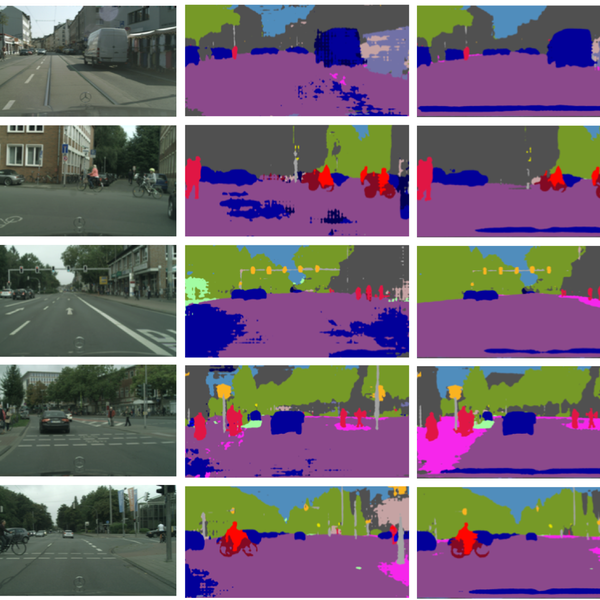

https://github.com/wasidennis/AdaptSegNet

**[아이스브레이킹] "유넷"으로 이행시를 지어보세요.**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

유 : 유례 없는 일이 벌어지고 있다. 유<br>
<br>
넷 : 넷과 함께하는 순간들은 항상 특별하다.</details>

이번 시간에는 Semantic Segmentation(시맨틱 세그멘테이션) 을 이용해서 자율주행차량이 주행해야 할 도로 영역을 찾는 상황을 가정하고 모델을 만들어보는 시간을 갖겠습니다. 앞서 강의 노드에서는 Semantic Segmentation을 위한 다양한 모델을 배워보았습니다. 이번 시간에는 U-Net을 사용해서 이미지가 입력되면 도로의 영역을 Segmentation 하는 모델을 만들어보겠습니다. \
\
최종적으로 만들어 볼 모델은 아래와 같습니다! 입력 이미지 위에 도로 영역으로 인식한 영역을 흰색으로 오버레이 한 이미지입니다.

<img src="https://d3s0tskafalll9.cloudfront.net/media/original_images/result.gif">

### **학습내용**
---

* 2. 시맨틱 세그멘테이션 데이터셋
  * Semantic Segmentation 학습을 위한 KITTI Dataset을 준비합니다.
* 3. 시맨틱 세그멘테이션 모델
  * U-Net model을 작성합니다.
* 4. 시맨틱 세그멘테이션 모델 시각화
  * 학습된 결과를 시각화합니다.

### **실습목표**
---

* 시맨틱 세그멘테이션 데이터셋을 전처리할 수 있습니다.
* 시맨틱 세그멘테이션 모델을 만들고 학습할 수 있습니다.
* 시맨틱 세그멘테이션 모델의 결과를 시각화할 수 있습니다.

## **20-2. 시맨틱 세그멘테이션 데이터셋**

### **이미지, 데이터 가져오기**
---

먼저 **시맨틱 세그멘테이션(semantic segmentation)** 으로 도로의 영역을 분리하기 위해서는 도로의 영역을 라벨로 가진 데이터셋을 가지고 학습할 수 있도록 파싱 해야 합니다. 아래 링크를 통해서 물체 검출(object detection)으로 사용했던 **KITTI 데이터셋의 세그멘테이션 데이터** 를 다운로드합니다. \
\
데이터 출처: http://www.cvlibs.net/datasets/kitti/eval_semantics.php



```
$ mkdir -p ~/aiffel/semantic_segmentation/data
$ wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
$ unzip data_semantics.zip -d ~/aiffel/semantic_segmentation/data
```



In [3]:
!mkdir -p ./aiffel/semantic_segmentation/data
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip data_semantics.zip -d ./aiffel/semantic_segmentation/data

--2026-09-03 01:57:10--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.121.117, 3.5.122.137, 3.5.121.56, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.121.117|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 327699796 (313M) [application/zip]
Saving to: ‘data_semantics.zip’

data_semantics.zip  100%[===================>] 312.52M  12.5MB/s    in 24s     

2026-09-03 01:57:35 (13.1 MB/s) - ‘data_semantics.zip’ saved [327699796/327699796]

Archive:  data_semantics.zip
   creating: ./aiffel/semantic_segmentation/data/testing/
   creating: ./aiffel/semantic_segmentation/data/testing/image_2/
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000000_10.png  
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000001_10.png  
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000002_10.png  


아래는 데이터셋에서 확인할 수있는 이미지와 라벨입니다. 지금까지 보던 라벨 데이터와 다르게 세그멘테이션 데이터는 이미지 형태의 라벨으로 되어있습니다.

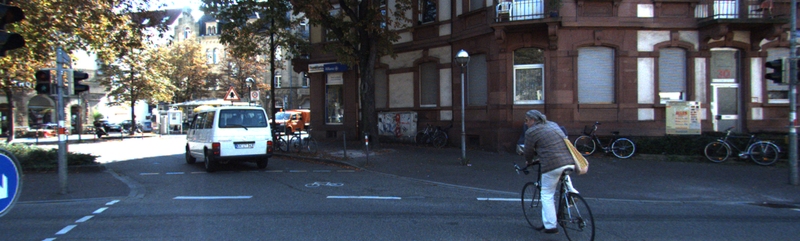

[KITTI 데이터셋]

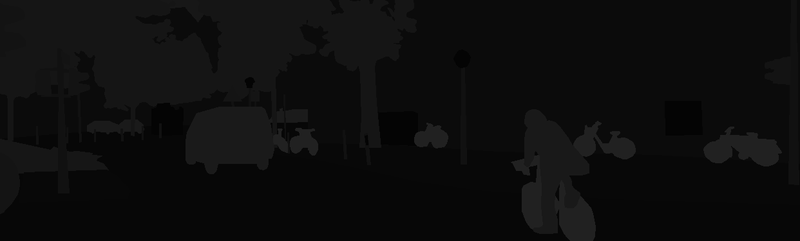

[KITTI 데이터셋 segmentation]

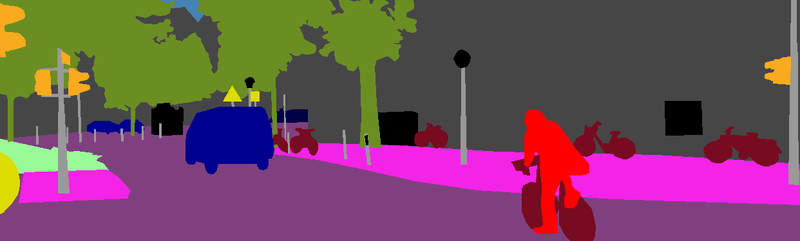

[KITTI 데이터셋 segmentation_rgb]

**Q. 시맨틱 세그멘테이션의 이미지 라벨의 각 pixel 값은 의미를 갖습니다. 그렇다면 오늘 우리가 시맨틱 세그멘테이션으로 찾아내야 할 도로의 label은 어떤 값일까요?**<br>
A. [ 답변을 적어볼까요! ]<br><br>
<details><summary>힌트</summary>

[라벨 정보](https://github.com/mcordts/cityscapesScripts/blob/master/cityscapesscripts/helpers/labels.py)를 참고하세요.</details>

<details><summary>💡예시답안 확인하기💡</summary>

7입니다.</details>

### **데이터 로더(data loader) 만들기**
---

이제 이미지와 데이터셋이 주어졌으니 모델을 학습시킬 수 있는 데이터 로더(data loader)를 만들어봅시다. 로더는 입력값 `(224, 224)`, 출력값 `(224, 244)` 크기를 갖는 모델을 학습시킬 수 있도록 데이터셋을 파싱 해야 합니다. \
\
이때 데이터 로더에 **augmentation** 을 적용해 봅시다. 오늘은 파이썬에서 많이 사용되는 `albumentations`을 사용해 보겠습니다. 하지만 Augmentation의 경우 `imgaug` 등 다른 라이브러리를 활용하셔도 됩니다.



```
$ pip install albumentations
```



In [4]:
# !pip install albumentations

또한 학습셋의 일정량을 **검증 데이터셋(validation dataset)** 으로 활용할 수 있도록 해야 합니다. \
\
만든 후에는 직접 데이터셋이 잘 파싱 되어 나오는지 꼭 확인해보세요. 데이터셋에 오류가 없어야 성능이 안 나오더라도 문제를 찾아내기 쉽습니다.

In [5]:
#필요한 라이브러리를 로드합니다.
import os
import math
import numpy as np
import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob

import torch.nn as nn
import torch.optim as optim

print('=3')

=3


Albumentation 의 사용법을 간단히 알아보겠습니다. 아래는 Albumentation에서 다양한 augmentation 기법을 확률적으로 적용할 수 있게 해주는 `Compose()`의 활용예입니다. imgaug의 `Sometimes()`와 유사한 기능입니다.

In [6]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        # [검수] height/width 인자는 최신 albumentations(>=1.4)에서 제거되어
                        #        UserWarning 후 무시됩니다. crop 크기는 size로만 지정합니다.
                        min_max_height=(300, 370),
                        size=(224, 224),
                        w2h_ratio=370/1242,
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        height=224,
                        width=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    height=224,
                    width=224
                    )
                ])


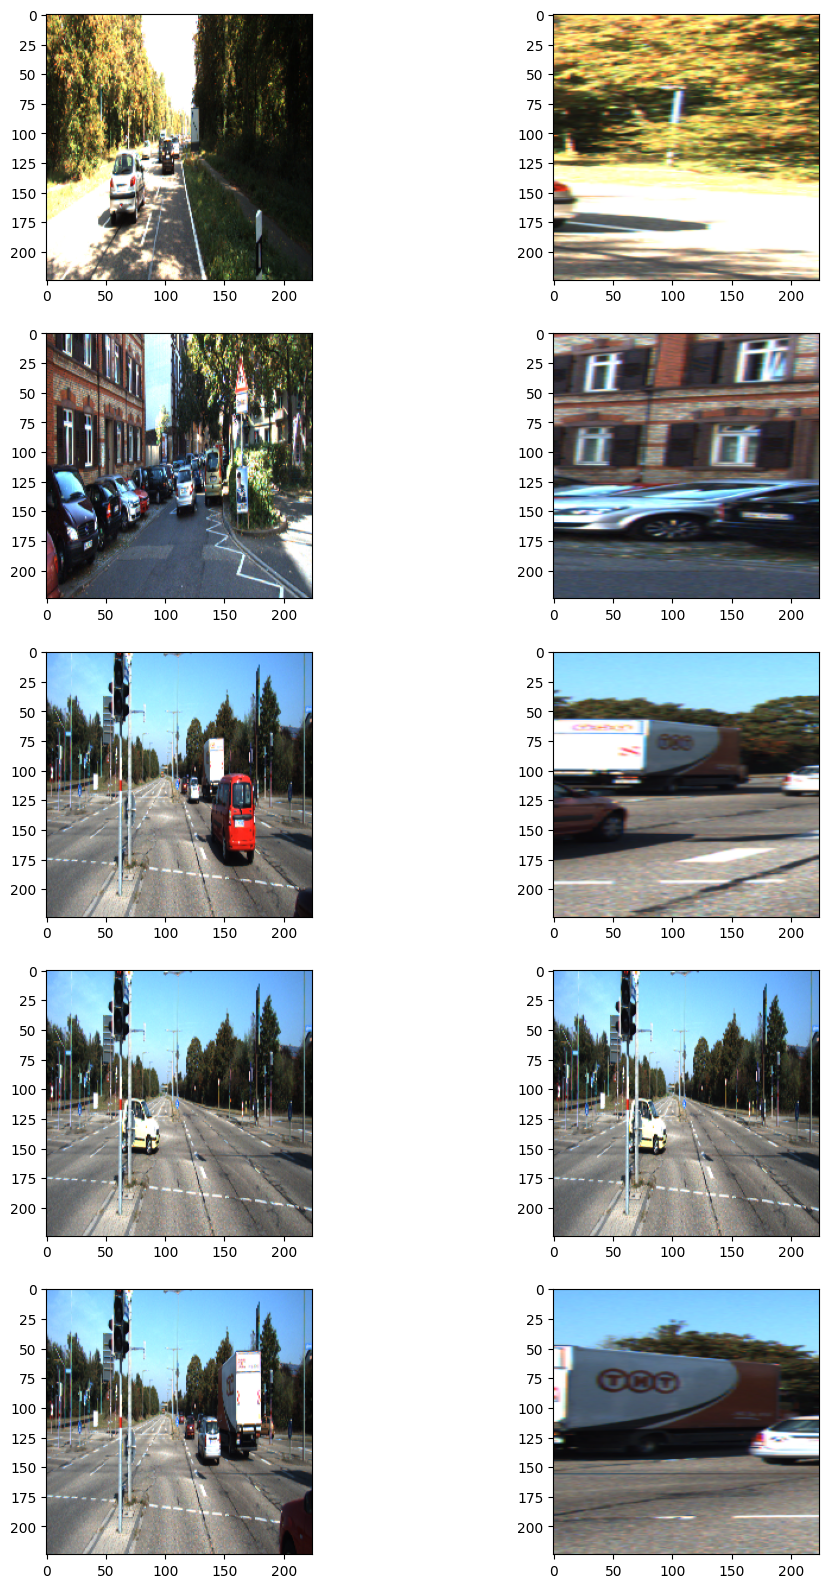

In [7]:
dir_path = "./aiffel/semantic_segmentation/data/training"

augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(dir_path, "image_2", "*.png"))

# 훈련 데이터셋에서 5개만 가져와 augmentation을 적용해 봅시다.
plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])  # 왼쪽이 원본이미지
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])  # 오른쪽이 augment된 이미지

plt.show()

이제 데이터셋을 구성해 봅시다. 이번에는 Dataset를 상속받은 generator 형태로 데이터를 구성해 보겠습니다.

In [8]:
from torch.utils.data import Dataset

class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받습니다.
    우리가 KittiDataset을 원하는 방식으로 preprocess하기 위해서 Dataset을 커스텀하여 사용합니다.
    '''
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path입니다.
        img_size: preprocess에 사용할 입력이미지의 크기입니다.
        output_size: ground_truth를 만들어주기 위한 크기입니다.
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분합니다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받습니다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인합니다.
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수입니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환합니다.
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듭니다.
        # 입력은 resize 및 augmentation이 적용된 input image이고
        # 출력은 semantic label입니다.
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # 📌 target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수입니다. 학습 중인 경우에 데이터를 random shuffle합니다.
        if self.is_train:
            np.random.shuffle(self.data)

In [9]:
from torch.utils.data import DataLoader

# Augmentation 설정
augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

train_dataset = KittiDataset(
    dir_path,
    augmentation=augmentation,
    is_train=True
)

test_dataset = KittiDataset(
    dir_path,
    augmentation=test_preproc,
    is_train=False
)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## **20-3. 시맨틱 세그멘테이션 모델**

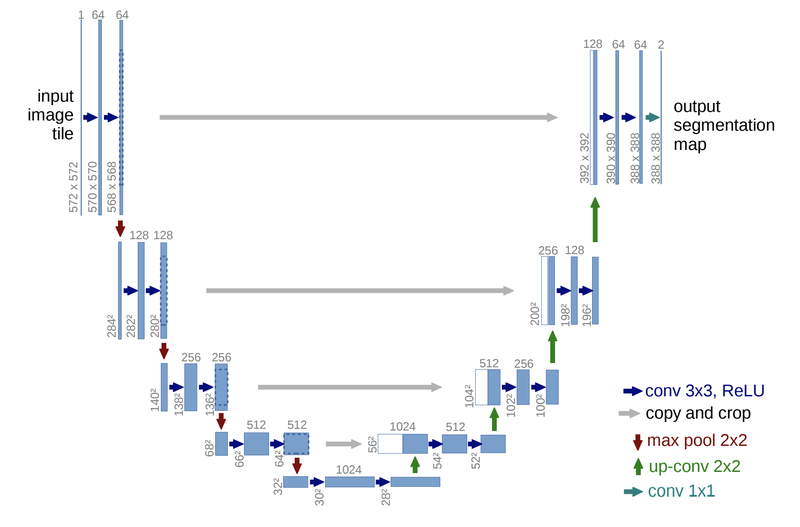

### **모델 구조 만들기**
---

시맨틱 세그멘테이션을 위한 모델을 만들어주세요. 세그멘테이션 모델 중 구조상 비교적 구현이 단순한 `U-Net`을 구현해 봅시다. \
\
이때 입력 이미지의 크기는 위에서 만든 데이터셋에 맞춰서 만들어주세요. \
\
사용에 필요한 레이어와 연산은 다음과 같습니다. 그리고 필요에 따라서 Dropout 등의 다른 레이어를 적용해 보세요.<br><br>

* **`double_conv`, `MaxPool2d`, `Dropout`, `ConvTranspose2d`, `Conv2d`, `ReLU`, `bottleneck`, `cat`, `sigmoid`**

In [10]:
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output

### **모델 학습하기**
---

이제 모델을 만들었으니 위에서 만들어본 데이터셋과 학습을 해봅시다! (모델 학습에 상당한 시간이 소요됨으로 학습이 잘 진행되는지 확인해 보시고 다음 스텝으로 넘어가셔서 이미 학습된 모델을 사용하셔도 됩니다.)

In [11]:
%%time

# 모델 저장 경로
model_path = "./aiffel/semantic_segmentation/seg_model_unet.pth"

# 모델 생성
model = UNet(input_channels=3, output_channels=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 손실 함수 및 옵티마이저 설정
criterion = torch.nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 데이터로더 준비
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 모델 학습
num_epochs = 100
unet_loss_history = [] # U-Net loss history list
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.float())  # 타겟을 float 타입으로 변환
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)
    unet_loss_history.append(epoch_loss) # Append epoch loss to history
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss}")

# 모델 저장
torch.save(model.state_dict(), model_path)

Epoch 1/100, Loss: 0.678658891807903
Epoch 2/100, Loss: 0.6219492825594816
Epoch 3/100, Loss: 0.5372550622983412
Epoch 4/100, Loss: 0.43123656240376557
Epoch 5/100, Loss: 0.38949537548151886
Epoch 6/100, Loss: 0.3593979992649772
Epoch 7/100, Loss: 0.3205387673594735
Epoch 8/100, Loss: 0.3034639927473935
Epoch 9/100, Loss: 0.2878100980411876
Epoch 10/100, Loss: 0.26157735830003565
Epoch 11/100, Loss: 0.23143535446036945
Epoch 12/100, Loss: 0.23883152414451947
Epoch 13/100, Loss: 0.2115606814622879
Epoch 14/100, Loss: 0.20614006979898972
Epoch 15/100, Loss: 0.20901423015377738
Epoch 16/100, Loss: 0.20923201468857852
Epoch 17/100, Loss: 0.20170902393080972
Epoch 18/100, Loss: 0.1969795199957761
Epoch 19/100, Loss: 0.19341130554676056
Epoch 20/100, Loss: 0.218921267173507
Epoch 21/100, Loss: 0.20040003819899124
Epoch 22/100, Loss: 0.16681815954771909
Epoch 23/100, Loss: 0.18177022310820493
Epoch 24/100, Loss: 0.17096591131253677
Epoch 25/100, Loss: 0.1715176979249174
Epoch 26/100, Loss: 0.

## **20-4. 시맨틱 세그멘테이션 모델 시각화**

이번에는 학습한 모델의 결과를 눈으로 확인해 볼 차례입니다. 우선 이전 스텝에서 저장한 모델이나 제공된 모델을 다음 코드를 통해 불러와 주세요.

In [12]:
model = UNet(input_channels=3, output_channels=1)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()  # 평가 모드로 전환

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc4): Sequential(
    (0): Con

테스트 셋은 이미지를 제공하지만 정답 데이터를 제공하지 않으니 눈으로 확인할 수 있도록 모델이 추론(inference)한 결과를 우리의 눈으로 볼 수 있는 세그멘테이션 이미지로 만들어주세요! \
\
이때 입력 이미지와 라벨을 한 번에 볼 수 있도록 모델의 출력값을 입력 이미지 위에 겹쳐서 보이기, 즉 **오버레이(overray)** 해 주세요. PIL 패키지를 사용하신다면 `Image.blend`를 활용하실 수 있습니다. \
\
`get_output`이라는 이름의 함수로 만들어 주세요.

In [13]:
def get_output(model, preproc, image_path, output_path):
    # 원본 이미지 로드
    origin_img = imread(image_path)
    data = {"image": origin_img}

    # 전처리 적용
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

    # 모델 추론 (inference)
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    # 시그모이드 활성화 후 임계값(0.5) 적용하여 바이너리 마스크 생성
    output = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255   #0.5라는 threshold를 변경하면 도로인식 결과범위가 달라집니다.
    output = Image.fromarray(output)

    # 배경과 결합하여 시각화 (Overlay)
    background = Image.fromarray(origin_img).convert('RGBA')
    output = output.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, output, alpha=0.5)

    # 변환된 이미지 저장
    blended.save(output_path)

    blended.show()
    return blended

위에서 작성한 함수를 이용해 시각화를 해봅시다.

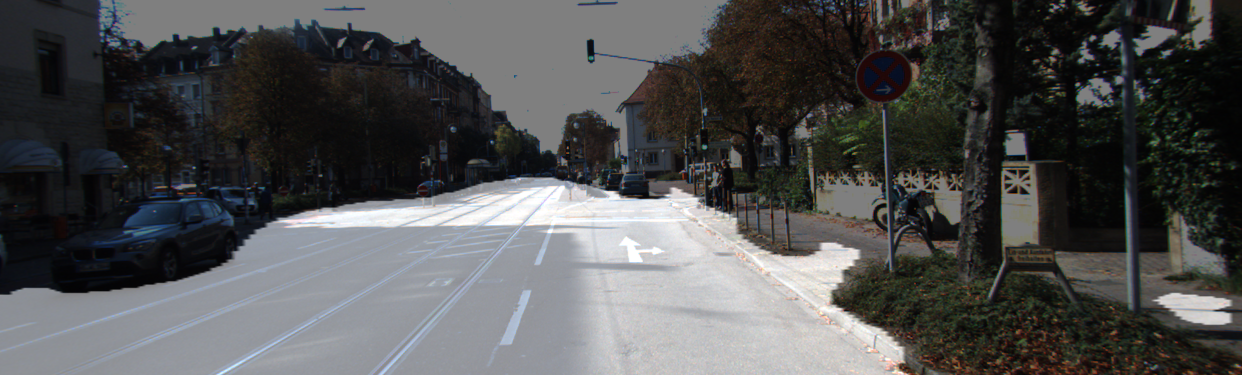

In [14]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png'
 )

세그멘테이션이 성능을 정량적으로 측정하기 위한 방법으로 IoU(Intersection over Union)를 계산하게 됩니다. IoU를 계산하는 방법은 지난 시간에 소개한 바 있으므로 해당 내용을 활용하여 구현해 보겠습니다. \
\
IoU를 계산하려면 모델이 도로 영역이라고 판단한 부분이 1로, 나머지 부분이 0으로 표시된 행렬, 그리고 라벨 데이터에서 도로 영역이 1, 나머지 부분이 0으로 표시된 행렬이 필요합니다. 각각을 `prediction`, `target`이라고 불렀을 때 이를 계산하는 함수를 구현해 보겠습니다. 위에 구현했던 `get_output`을 좀 더 확장해서 output, prediction, target을 함께 리턴하도록 구현해 봅시다.

In [15]:
def calculate_iou_score(target, prediction):
    if target.shape != prediction.shape:
        prediction = resize(prediction, target.shape, mode='constant', preserve_range=True).astype(np.uint8)

    intersection = np.logical_and(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    union = np.logical_or(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    iou_score = intersection / (union + 1e-7)  # iou 스코어를 구하되 결과값을 float로 만들어주세요!
    print(f"IoU : {iou_score:.6f}")
    return iou_score

In [16]:
def get_output(model, preproc, image_path, output_path, label_path=None):
    origin_img = imread(image_path)
    data = {"image": origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32)
    input_tensor = input_tensor.permute(2, 0, 1).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    prediction = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255
    prediction = Image.fromarray(prediction).convert('L')

    background = Image.fromarray(origin_img).convert('RGBA')
    prediction_resized = prediction.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, prediction_resized, alpha=0.5)

    blended.save(output_path)
    blended.show()

    target = None
    if label_path:
        label_img = imread(label_path)
        # [검수] 라벨을 preproc(image=...)로 넣으면 Resize가 bilinear 보간을 적용해
        #        경계의 라벨값이 뭉개지고( 7 != 보간값 ) IoU의 정답(target)이 오염됩니다.
        #        라벨은 반드시 mask로 전달해 nearest 보간이 적용되도록 합니다.
        #        (KittiDataset.__getitem__ 이 이미 쓰는 방식과 동일하게 맞춰 일관성 유지)
        label_bin = (label_img == 7).astype(np.uint8)          # 먼저 도로 이진 마스크 생성
        target = preproc(image=origin_img, mask=label_bin)["mask"]   # mask는 nearest 보간

    return blended, np.array(prediction), target


In [17]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
output, prediction, target = get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png',
     label_path=dir_path + f'/semantic/00{str(i).zfill(4)}_10.png'
 )

calculate_iou_score(target, prediction)

IoU : 0.884210


np.float64(0.8842097762513594)

# **21. 도로 영역을 찾자! - 세그멘테이션 모델 만들기 [프로젝트]**

## **21-1. 프로젝트 : 개선된 U-Net 모델 만들기**

U-Net을 통한 시맨틱 세그멘테이션 결과가 충분히 만족스러우신가요? 어느 정도 동작하는 것 같긴 하지만 좀 더 개선할 여지도 보일 것입니다.<br>
<br>
2018년에 U-Net++라는 논문이 나왔습니다. 이 논문은 기존에 아주 단순하면서도 세그멘테이션에서 효과를 발휘했던 U-Net의 네트워크 구조에 DenseNet의 아이디어를 가미하여 성능을 개선한 모델입니다. 논문은 2020년에 한 번 업그레이드가 되었네요.<br>
<br>
- [U-Net++: v1](https://arxiv.org/abs/1807.10165)
- [U-Net++: v2](https://arxiv.org/abs/1912.05074)
<br><br>

모델의 구조 자체는 아래 그림에서 보는 것처럼 별다른 설명이 없이도 직관적으로 이해가 가능한 수준입니다. 오늘 소개되었던 U-Net의 모델 코드를 조금만 수정 확장하면 충분히 구현할 수 있을 것입니다. 그래서 오늘의 과제는 바로 U-Net++ 모델을 스스로의 힘으로 직접 구현해 보고, U-Net을 활용했던 도로 세그멘테이션 태스크에 적용하여 U-Net을 썼을 때보다 성능이 향상되었음을 확인해 보는 것입니다. 정성적으로는 두 모델의 세그멘테이션 결과를 시각화해서 비교해 볼 수 있을 것이고, 정량적으로는 동일 이미지에 대한 IoU 값을 비교해 보면 될 것입니다.

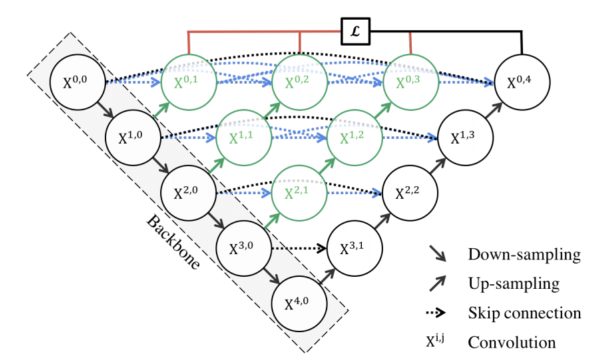

참고할 수 있는 코드는 아래에 있습니다. 다행히도 keras로 구현되어 있습니다.<br>
<br>
- [U-Net++:Github](https://github.com/MrGiovanni/UNetPlusPlus)
<br><br>

코드 중에서 가장 중요한 부분도 알려드리자면 [여기:build_xnet](https://github.com/MrGiovanni/UNetPlusPlus/blob/e145ba63862982bf1099cf2ec11d5466b434ae0b/keras/segmentation_models/xnet/builder.py#L12)입니다. 논문에서 제시하는 수식과 함께 참고하세요.

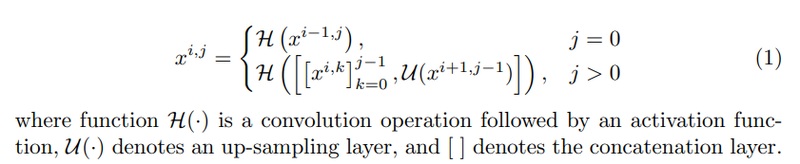

[H와 u와 []가 무엇인지 주목하세요]<br>
https://arxiv.org/pdf/1807.10165.pdf

코드 중 `up_block`으로는 두 가지 방식을 사용하고 있네요. [Transpose2D_block](https://github.com/MrGiovanni/UNetPlusPlus/blob/e145ba63862982bf1099cf2ec11d5466b434ae0b/keras/segmentation_models/xnet/blocks.py#L53)과 [Upsample2D_block](https://github.com/MrGiovanni/UNetPlusPlus/blob/e145ba63862982bf1099cf2ec11d5466b434ae0b/keras/segmentation_models/xnet/blocks.py#L28)인데요. 둘 중 어느 것을 사용해도 좋습니다.<br>
<br>
또 한 가지 주의해야 할 점은 Loss를 조금 다르게 구현해야 한다는 점입니다. binary cross-entropy와 dice coefficient를 사용한다고 하는데요. [dice_coef](https://github.com/MrGiovanni/UNetPlusPlus/blob/e145ba63862982bf1099cf2ec11d5466b434ae0b/keras/helper_functions.py#L37)에 구현된 dice coefficient를 참고해 보세요.

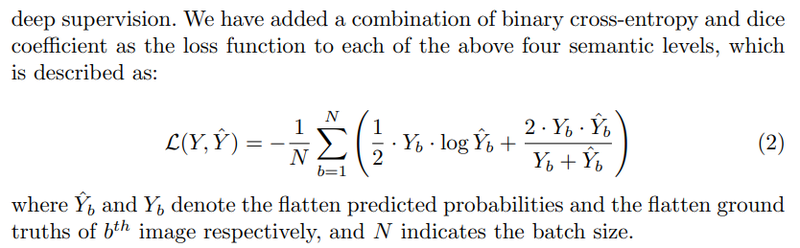

[binary cross-entropy와 dice coefficient를 이용합니다]<br>
https://arxiv.org/pdf/1807.10165.pdf

프로젝트 진행에 필요한 주요 라이브러리 버전 체크를 해봅시다.

In [18]:
import torch
import numpy as np
import PIL
import skimage
import albumentations

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(skimage.__version__)
print(albumentations.__version__)

2.11.0+cu128
2.1.3
11.3.0
0.25.2
2.0.8


### **Step 1. KITTI 데이터셋 수집과 구축**

### Ablation Study 1: U-Net vs U-Net++ 초기 성능 비교
- **U-Net 평균 IoU:** 0.7206
- **U-Net++ 평균 IoU:** 0.7686
- **결론:** U-Net++ 모델이 U-Net에 비해 더 높은 평균 IoU를 달성하여 우수한 세그멘테이션 성능을 보였습니다.

### Ablation Study 2: U-Net++ 성능 향상 (Hyperparameter Tuning)
- **목표:** U-Net++의 성능을 더욱 향상시키기 위해 하이퍼파라미터를 조정합니다.
- **변경 사항:** 학습률(Learning Rate)을 낮추어 안정적인 수렴을 유도하고, 학습 에포크(Epoch)를 늘려 충분히 학습되도록 CONFIG를 직접 수정합니다. (LR: 1e-4 -> 5e-5, Epochs: 100 -> 150)
- **결과:** U-Net++ 평균 IoU: 0.7841
- **결론:** 하이퍼파라미터 튜닝을 통해 U-Net++의 성능이 기존 0.7686에서 0.7841로 향상되었습니다. 더 긴 에포크와 낮은 학습률이 모델의 안정적인 수렴과 세그멘테이션 품질 개선에 기여했음을 확인했습니다.

In [19]:
class CONFIG:
    # Dataset and DataLoader Configuration
    DIR_PATH = "./aiffel/semantic_segmentation/data/training" # 데이터셋 경로
    IMG_SIZE = (224, 224, 3) # 입력 이미지 크기 (높이, 너비, 채널)
    OUTPUT_SIZE = (224, 224) # 출력 마스크 크기 (높이, 너비)
    BATCH_SIZE = 8 # U-Net++의 메모리 관리를 위해 배치 크기 감소
    SHUFFLE_TRAIN_DATA = True # 훈련 데이터 셔플 여부
    VALIDATION_SPLIT = 30 # 검증 데이터로 사용할 샘플 수

    # Model Hyperparameters
    UNET_INPUT_CHANNELS = 3 # U-Net 입력 채널 수
    UNET_OUTPUT_CHANNELS = 1 # U-Net 출력 채널 수 (도로 영역 이진 마스크)
    UNET_DROPOUT_RATE = 0.5 # U-Net 드롭아웃 비율

    # Training Hyperparameters
    # [Ablation Study 2] U-Net++ 성능 향상을 위해 하이퍼파라미터 수정
    LEARNING_RATE = 5e-5 # 학습률 감소 (기존 1e-4 -> 5e-5)
    NUM_EPOCHS = 150 # 에포크 수 증가 (기존 100 -> 150)

    # Model Saving Paths
    UNET_MODEL_PATH = "./aiffel/semantic_segmentation/seg_model_unet.pth" # U-Net 모델 저장 경로
    # [Ablation Study 2] 새로운 가중치 저장을 위해 경로 수정
    UNETPP_MODEL_PATH = "./aiffel/semantic_segmentation/seg_model_unetpp_ablation2.pth" # U-Net++ 모델 저장 경로

    # IoU Calculation Threshold
    IOU_THRESHOLD = 0.5 # IoU 계산 시 예측 마스크 이진화 임계값

    # Label for road segmentation
    ROAD_LABEL = 7 # 도로 영역을 나타내는 라벨 값 (KITTI 데이터셋 기준)

# 설정 값을 출력하여 확인합니다.
for key, value in vars(CONFIG).items():
    if not key.startswith('__') and not callable(value):
        print(f'{key}: {value}')

DIR_PATH: ./aiffel/semantic_segmentation/data/training
IMG_SIZE: (224, 224, 3)
OUTPUT_SIZE: (224, 224)
BATCH_SIZE: 8
SHUFFLE_TRAIN_DATA: True
VALIDATION_SPLIT: 30
UNET_INPUT_CHANNELS: 3
UNET_OUTPUT_CHANNELS: 1
UNET_DROPOUT_RATE: 0.5
LEARNING_RATE: 5e-05
NUM_EPOCHS: 150
UNET_MODEL_PATH: ./aiffel/semantic_segmentation/seg_model_unet.pth
UNETPP_MODEL_PATH: ./aiffel/semantic_segmentation/seg_model_unetpp_ablation2.pth
IOU_THRESHOLD: 0.5
ROAD_LABEL: 7


다운로드한 KITTI 데이터에 data augmentation을 적용한 형태로 데이터셋을 구축합니다. 이때 주의할 점이 있습니다. U-Net++는 메모리 사용량이 U-Net보다 꽤 많아집니다. 그러니 배치 사이즈를 적절히 줄여서 설정하시기를 권합니다.

In [20]:
# KittiDataset 클래스를 CONFIG 변수를 사용하도록 수정합니다.
class KittiDataset(Dataset):
    def __init__(self,
                 dir_path,
                 img_size=CONFIG.IMG_SIZE,
                 output_size=CONFIG.OUTPUT_SIZE,
                 is_train=True,
                 augmentation=None):
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size
        self.data = self.load_dataset()

    def load_dataset(self):
        # 입력 이미지와 라벨 이미지 경로를 불러옵니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))
        assert len(input_images) == len(label_images), "입력 이미지와 라벨 이미지의 수가 일치해야 합니다."
        data = list(zip(input_images, label_images))

        # 훈련 데이터와 검증 데이터 분할
        if self.is_train:
            return data[:-CONFIG.VALIDATION_SPLIT]
        return data[-CONFIG.VALIDATION_SPLIT:]

    def __len__(self):
        # 데이터셋의 총 길이 반환
        return len(self.data)

    def __getitem__(self, index):
        # 인덱스에 해당하는 이미지와 라벨을 불러옵니다.
        input_img_path, output_path = self.data[index]
        _input = imread(input_img_path)
        _output = imread(output_path)

        # CONFIG.ROAD_LABEL을 사용하여 도로 영역을 이진 마스크로 변환합니다.
        _output = (_output == CONFIG.ROAD_LABEL).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        # Augmentation 적용 (훈련 시)
        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # 이미지 정규화
            _output = augmented["mask"]

        # 출력 마스크 차원 확장 (H, W) -> (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1), # 이미지 텐서 변환 (H, W, C) -> (C, H, W)
            torch.tensor(_output, dtype=torch.float32) # 마스크 텐서
        )

    def shuffle_data(self):
        # 학습 시 데이터 셔플
        if self.is_train:
            np.random.shuffle(self.data)


# DataLoader 인스턴스 생성 시 CONFIG 변수를 사용하도록 업데이트합니다.
# 훈련 데이터셋 생성
train_dataset = KittiDataset(
    CONFIG.DIR_PATH,
    augmentation=augmentation,
    is_train=True
)

# 테스트 데이터셋 생성
test_dataset = KittiDataset(
    CONFIG.DIR_PATH,
    augmentation=test_preproc,
    is_train=False
)

# 훈련 DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=CONFIG.SHUFFLE_TRAIN_DATA)
# 테스트 DataLoader 생성
test_loader = DataLoader(test_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=False)

print("KittiDataset과 DataLoaders가 CONFIG 변수를 사용하여 업데이트되었습니다.")

KittiDataset과 DataLoaders가 CONFIG 변수를 사용하여 업데이트되었습니다.


### **Step 2. U-Net++ 모델의 구현**

U-Net의 모델 구조와 소스코드를 면밀히 비교해 보다 보면, U-Net++를 어떻게 구현할 수 있을지에 대한 방안을 떠올릴 수 있을 것입니다. 이 과정을 통해 U-Net 자체에 대한 이해도도 증진될 것입니다. 그 외 적절히 U-Net의 백본 구조, 기타 파라미터 변경 등을 통해 추가적인 성능 향상이 가능할 수도 있습니다.

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 기본적인 Convolution 블록 정의
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), # 3x3 컨볼루션
            nn.BatchNorm2d(out_channels), # 배치 정규화
            nn.ReLU(inplace=True), # ReLU 활성화 함수
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# U-Net++ 모델 정의
class UNetPlusPlus(nn.Module):
    def __init__(self, input_channels=3, output_channels=1, num_filters=[32, 64, 128, 256, 512]):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2) # 맥스 풀링
        # 업샘플링 (bilinear 보간법 사용)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # L0 인코더 경로 (U-Net의 다운샘플링 경로)
        self.conv0_0 = ConvBlock(input_channels, num_filters[0])
        self.conv1_0 = ConvBlock(num_filters[0], num_filters[1])
        self.conv2_0 = ConvBlock(num_filters[1], num_filters[2])
        self.conv3_0 = ConvBlock(num_filters[2], num_filters[3])
        self.conv4_0 = ConvBlock(num_filters[3], num_filters[4]) # 가장 깊은 계층

        # L1 중간 경로
        # 각 노드는 이전 레벨의 출력과 업샘플링된 다음 레벨의 출력을 연결합니다.
        self.conv0_1 = ConvBlock(num_filters[0] + num_filters[1], num_filters[0])
        self.conv1_1 = ConvBlock(num_filters[1] + num_filters[2], num_filters[1])
        self.conv2_1 = ConvBlock(num_filters[2] + num_filters[3], num_filters[2])
        self.conv3_1 = ConvBlock(num_filters[3] + num_filters[4], num_filters[3])

        # L2 중간 경로
        self.conv0_2 = ConvBlock(num_filters[0]*2 + num_filters[1], num_filters[0]) # Dense 연결
        self.conv1_2 = ConvBlock(num_filters[1]*2 + num_filters[2], num_filters[1])
        self.conv2_2 = ConvBlock(num_filters[2]*2 + num_filters[3], num_filters[2])

        # L3 중간 경로
        self.conv0_3 = ConvBlock(num_filters[0]*3 + num_filters[1], num_filters[0]) # Dense 연결
        self.conv1_3 = ConvBlock(num_filters[1]*3 + num_filters[2], num_filters[1])

        # L4 가장 바깥쪽 디코더 경로 (출력 경로)
        self.conv0_4 = ConvBlock(num_filters[0]*4 + num_filters[1], num_filters[0]) # Dense 연결

        # 최종 출력 레이어 (1x1 컨볼루션 및 시그모이드 활성화)
        self.final = nn.Conv2d(num_filters[0], output_channels, kernel_size=1)

    def forward(self, x):
        # 인코더 경로 (x0_0 ~ x4_0)
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))

        # 디코더 L1 경로
        # x0_0과 x1_0의 업샘플링 결과를 연결하여 x0_1 생성
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], 1))

        # 디코더 L2 경로
        # x0_0, x0_1, x1_1의 업샘플링 결과를 연결하여 x0_2 생성 (Dense 연결)
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))

        # 디코더 L3 경로
        # x0_0, x0_1, x0_2, x1_2의 업샘플링 결과를 연결하여 x0_3 생성
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))

        # 디코더 L4 경로
        # x0_0, x0_1, x0_2, x0_3, x1_3의 업샘플링 결과를 연결하여 x0_4 생성
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))

        # 최종 출력에 시그모이드 활성화 함수 적용 (이진 분류)
        output = torch.sigmoid(self.final(x0_4))
        return output

print("U-Net++ 모델이 정의되었습니다.")

U-Net++ 모델이 정의되었습니다.


In [22]:
import torch.optim as optim

# DiceBCELoss (Dice Loss + Binary Cross-Entropy Loss) 정의
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        # 모델 출력은 이미 시그모이드(sigmoid)를 통과했습니다.
        inputs = inputs.view(-1) # 1D로 펼치기
        targets = targets.view(-1) # 1D로 펼치기

        # 교집합 (Intersection) 계산
        intersection = (inputs * targets).sum()
        # Dice Loss 계산 (1 - Dice Coefficient)
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        # Binary Cross-Entropy Loss 계산
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        # Dice Loss와 BCE Loss 합산
        Dice_BCE = BCE + dice_loss

        return Dice_BCE

# U-Net++ 모델 학습
print("U-Net++ 학습 중...")
# U-Net++ 모델 인스턴스 생성
model_unetpp = UNetPlusPlus(input_channels=CONFIG.UNET_INPUT_CHANNELS, output_channels=CONFIG.UNET_OUTPUT_CHANNELS)
# GPU 사용 가능 시 GPU, 아니면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_unetpp.to(device) # 모델을 지정된 디바이스로 이동

# 손실 함수 및 옵티마이저 설정
criterion = DiceBCELoss() # DiceBCELoss 사용
optimizer = optim.Adam(model_unetpp.parameters(), lr=CONFIG.LEARNING_RATE) # Adam 옵티마이저 사용

unetpp_loss_history = [] # U-Net++ 손실 기록을 위한 리스트

# 에포크 수만큼 학습 반복
for epoch in range(CONFIG.NUM_EPOCHS):
    model_unetpp.train() # 모델을 훈련 모드로 설정
    running_loss = 0.0
    # 훈련 데이터 로더에서 배치 단위로 데이터 가져오기
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device) # 데이터를 디바이스로 이동

        optimizer.zero_grad() # 옵티마이저의 기울기 초기화
        outputs = model_unetpp(inputs) # 모델 순전파
        loss = criterion(outputs, targets.float()) # 손실 계산 (타겟을 float 타입으로 변환)
        loss.backward() # 역전파를 통해 기울기 계산
        optimizer.step() # 옵티마이저를 사용하여 가중치 업데이트

        running_loss += loss.item() # 현재 배치의 손실을 누적

    epoch_loss = running_loss/len(train_loader) # 에포크 당 평균 손실 계산
    unetpp_loss_history.append(epoch_loss) # 손실 기록 리스트에 추가

    # 매 에포크마다 손실 출력 (U-Net과 동일한 형태)
    print(f"Epoch {epoch+1}/{CONFIG.NUM_EPOCHS}, Loss: {epoch_loss}")

# 학습된 U-Net++ 모델의 state_dict 저장
torch.save(model_unetpp.state_dict(), CONFIG.UNETPP_MODEL_PATH)
print(f"U-Net++ 모델이 {CONFIG.UNETPP_MODEL_PATH} 에 저장되었습니다.")

U-Net++ 학습 중...
Epoch 1/150, Loss: 1.081033316525546
Epoch 2/150, Loss: 0.9330621524290605
Epoch 3/150, Loss: 0.8866363547065041
Epoch 4/150, Loss: 0.8098835484548048
Epoch 5/150, Loss: 0.8076825846325267
Epoch 6/150, Loss: 0.7936173569072377
Epoch 7/150, Loss: 0.7738033587282355
Epoch 8/150, Loss: 0.7441010122949426
Epoch 9/150, Loss: 0.7700724412094463
Epoch 10/150, Loss: 0.7689398256215182
Epoch 11/150, Loss: 0.738997760144147
Epoch 12/150, Loss: 0.7335876280611212
Epoch 13/150, Loss: 0.7462806105613708
Epoch 14/150, Loss: 0.7399823773990978
Epoch 15/150, Loss: 0.7222206646745856
Epoch 16/150, Loss: 0.7202886776490645
Epoch 17/150, Loss: 0.6851773424582048
Epoch 18/150, Loss: 0.7131345515901392
Epoch 19/150, Loss: 0.7166502313180403
Epoch 20/150, Loss: 0.6640240956436504
Epoch 21/150, Loss: 0.701221680099314
Epoch 22/150, Loss: 0.654057112607089
Epoch 23/150, Loss: 0.655170047825033
Epoch 24/150, Loss: 0.6657951338724657
Epoch 25/150, Loss: 0.6601469462568109
Epoch 26/150, Loss: 0.6

In [23]:
# U-Net++ 모델을 불러와 평가 모드로 설정합니다.
# 먼저 U-Net++ 모델의 아키텍처를 정의합니다.
model_unetpp_loaded = UNetPlusPlus(input_channels=CONFIG.UNET_INPUT_CHANNELS, output_channels=CONFIG.UNET_OUTPUT_CHANNELS)
# 저장된 모델의 가중치를 불러옵니다. (CPU에 매핑)
model_unetpp_loaded.load_state_dict(torch.load(CONFIG.UNETPP_MODEL_PATH, map_location=torch.device('cpu')))
model_unetpp_loaded.eval()  # 모델을 평가 모드로 전환 (Dropout, BatchNorm 등이 추론 모드로 동작)
# 불러온 모델의 구조를 출력하여 확인합니다.
display(model_unetpp_loaded)

UNetPlusPlus(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (up): Upsample(scale_factor=2.0, mode='bilinear')
  (conv0_0): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (conv1_0): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_ru

In [24]:
def evaluate_model(model_instance, model_path, test_loader, device):
    # 모델 가중치를 로드하고 디바이스로 이동합니다.
    model_instance.load_state_dict(torch.load(model_path, map_location=device))
    model_instance.to(device)
    model_instance.eval() # 모델을 평가 모드로 설정

    total_iou = 0 # 총 IoU 점수 초기화
    count = 0 # 처리된 이미지 수 초기화

    # 기울기 계산을 비활성화하여 메모리 사용량을 줄이고 계산 속도를 높입니다.
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device) # 데이터를 디바이스로 이동
            outputs = model_instance(inputs) # 모델 추론

            # 모델 출력을 이진 마스크로 변환합니다. (IoU 임계값 사용)
            preds = (outputs > CONFIG.IOU_THRESHOLD).float()
            targets = targets.float() # 타겟 마스크도 float 타입으로 변환

            # 배치 내 각 이미지에 대해 IoU 계산
            for i in range(inputs.size(0)):
                pred_np = preds[i].squeeze().cpu().numpy() # 예측 마스크를 NumPy 배열로 변환
                target_np = targets[i].squeeze().cpu().numpy() # 실제 마스크를 NumPy 배열로 변환

                # 교집합 (Intersection)과 합집합 (Union) 계산
                intersection = np.logical_and(target_np, pred_np).sum()
                union = np.logical_or(target_np, pred_np).sum()
                if union > 0: # 합집합이 0이 아닌 경우에만 IoU 계산
                    iou = intersection / union
                    total_iou += iou
                count += 1 # 처리된 이미지 수 증가

    # 평균 IoU 반환 (처리된 이미지가 없으면 0 반환)
    return total_iou / count if count > 0 else 0

print("U-Net 평가 중...")
# U-Net 모델 인스턴스 생성
unet_model = UNet(input_channels=CONFIG.UNET_INPUT_CHANNELS, output_channels=CONFIG.UNET_OUTPUT_CHANNELS)
# U-Net 모델의 평균 IoU 계산
unet_iou = evaluate_model(unet_model, CONFIG.UNET_MODEL_PATH, test_loader, device)

print("U-Net++ 평가 중...")
# U-Net++ 모델의 평균 IoU 계산 (학습된 model_unetpp 재사용)
unetpp_iou = evaluate_model(model_unetpp, CONFIG.UNETPP_MODEL_PATH, test_loader, device)

print(f"평균 IoU - U-Net: {unet_iou:.4f}")
print(f"평균 IoU - U-Net++: {unetpp_iou:.4f}")

U-Net 평가 중...
U-Net++ 평가 중...
평균 IoU - U-Net: 0.7706
평균 IoU - U-Net++: 0.7841


### PyTorch 모델 저장하고 불러오기 (Save & Load)
PyTorch에서는 보통 모델의 학습된 파라미터(가중치와 편향)를 담고 있는 딕셔너리인 `state_dict`를 저장하고 불러옵니다.

In [25]:
import torch

# 1. 모델 저장하기 (Save)
save_path = './aiffel/semantic_segmentation/my_unetpp_model.pth' # 모델 저장 경로 설정

# model_unetpp의 state_dict(학습된 가중치 및 편향)만 저장합니다. 이는 모델의 구조를 저장하는 것이 아닙니다.
torch.save(model_unetpp.state_dict(), save_path)
print(f"모델이 성공적으로 저장되었습니다: {save_path}")

# 2. 모델 불러오기 (Load)
# 모델을 불러올 때는, 저장할 때와 동일한 구조의 모델 객체가 먼저 선언되어 있어야 합니다.
# 비어 있는 U-Net++ 모델 아키텍처를 생성합니다.
loaded_model = UNetPlusPlus(input_channels=CONFIG.UNET_INPUT_CHANNELS, output_channels=CONFIG.UNET_OUTPUT_CHANNELS)

# 저장했던 state_dict를 불러와서 새로 생성한 모델 객체에 덮어씌웁니다.
# map_location은 모델을 로드할 장치(CPU 또는 GPU)를 지정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.load_state_dict(torch.load(save_path, map_location=device))

# 추론(Inference)이나 평가(Evaluation)를 위해 불러온 모델은 반드시 eval() 모드로 변경해야 합니다.
# 이는 Dropout 레이어와 BatchNorm 레이어 등이 추론 시에는 학습 모드와 다르게 동작하도록 합니다.
loaded_model.eval()
loaded_model.to(device) # 모델을 지정된 디바이스로 이동
print("모델을 성공적으로 불러와 평가 모드(eval)로 전환했습니다!")

모델이 성공적으로 저장되었습니다: ./aiffel/semantic_segmentation/my_unetpp_model.pth
모델을 성공적으로 불러와 평가 모드(eval)로 전환했습니다!


### **Step 3. U-Net 과 U-Net++ 모델이 수행한 세그멘테이션 결과 분석**

두 모델의 정량적, 정성적 성능을 비교해 봅시다. 시각화, IoU 계산 등을 체계적으로 시도해 보면 차이를 발견하실 수 있을 것입니다.

=== 정성적 및 정량적 비교 ===


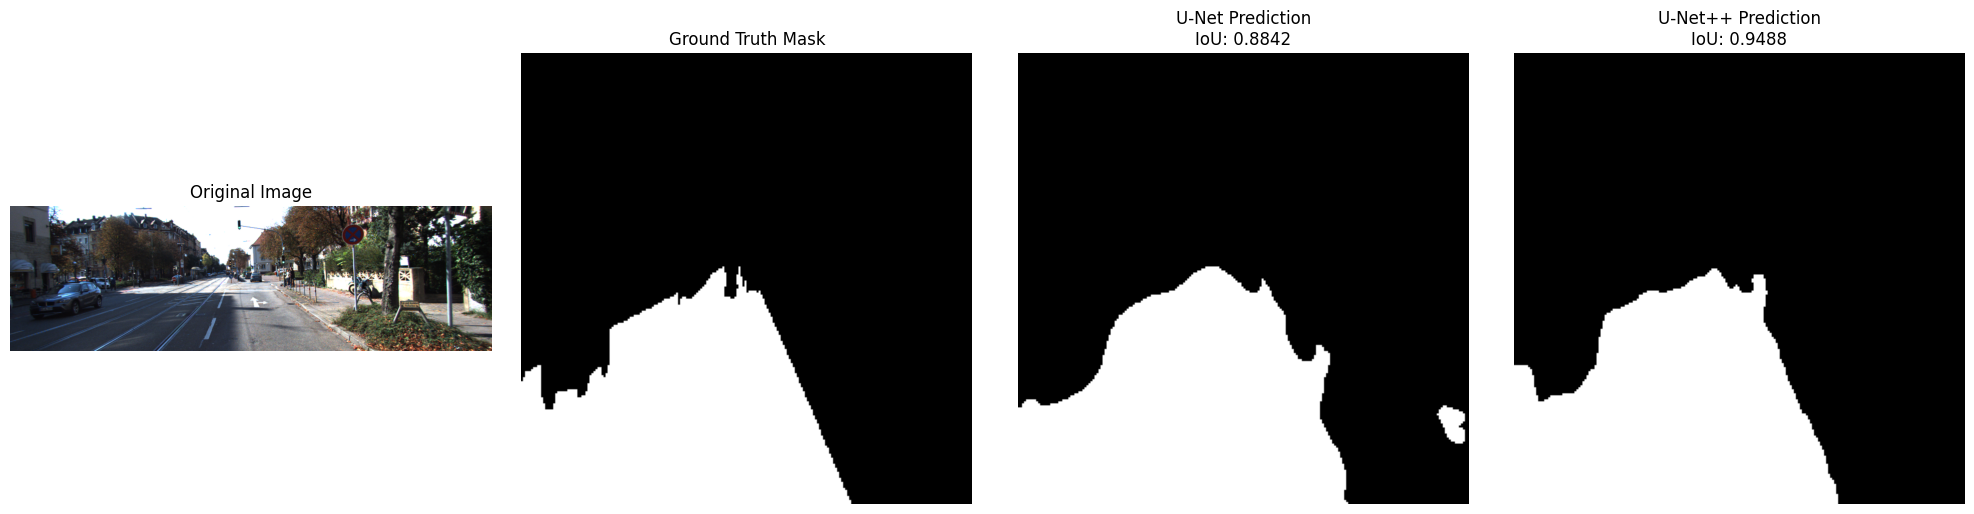

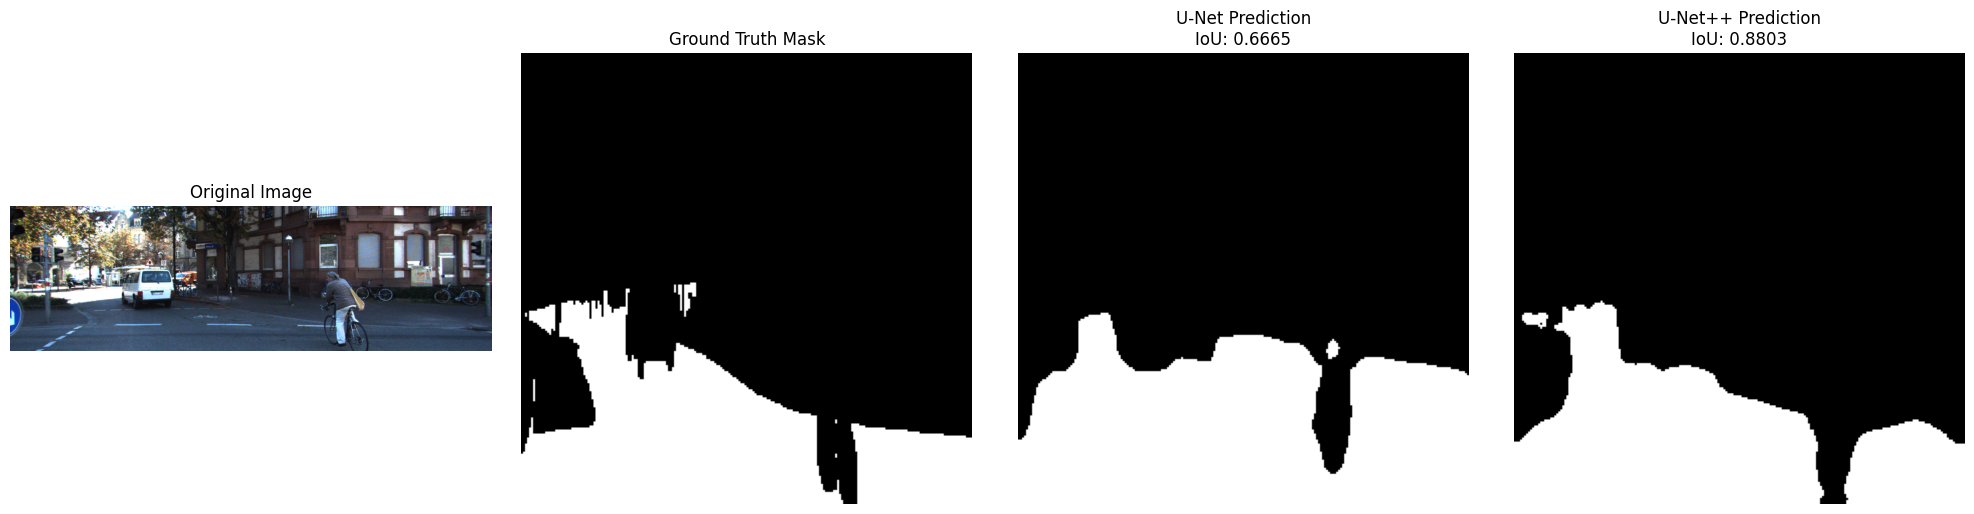

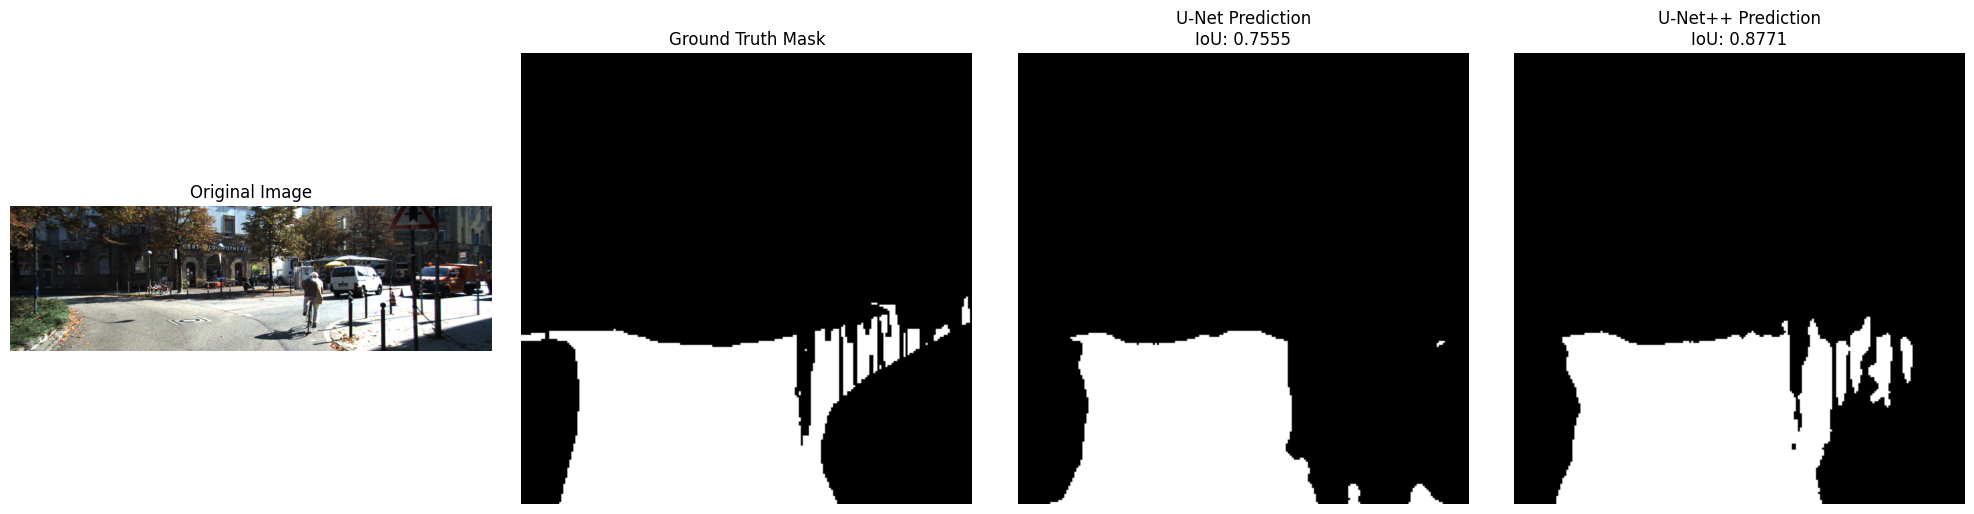

In [26]:
import matplotlib.pyplot as plt
import os

def compare_models_visually(model1, model2, preproc, image_path, label_path, device):
    # 원본 이미지와 라벨 이미지 로드
    origin_img = imread(image_path)
    label_img = imread(label_path)

    # 이미지를 전처리하고 텐서 형태로 변환하여 모델 입력으로 준비합니다.
    data = {"image": origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    # Ground Truth 마스크 생성 (도로 라벨 = 7)
    label_bin = (label_img == CONFIG.ROAD_LABEL).astype(np.uint8)
    # 라벨 마스크를 전처리 (resize)하여 모델 출력 크기에 맞춥니다.
    target = preproc(image=origin_img, mask=label_bin)["mask"]

    # 첫 번째 모델 (U-Net)으로 예측 수행
    model1.eval() # 평가 모드 설정
    with torch.no_grad(): # 기울기 계산 비활성화
        out1 = model1(input_tensor)
    # 예측 결과를 이진 마스크로 변환 (임계값 0.5)
    pred1 = (out1[0].squeeze().cpu().numpy() > CONFIG.IOU_THRESHOLD).astype(np.uint8)

    # 두 번째 모델 (U-Net++)으로 예측 수행
    model2.eval() # 평가 모드 설정
    with torch.no_grad(): # 기울기 계산 비활성화
        out2 = model2(input_tensor)
    # 예측 결과를 이진 마스크로 변환 (임계값 0.5)
    pred2 = (out2[0].squeeze().cpu().numpy() > CONFIG.IOU_THRESHOLD).astype(np.uint8)

    # 각 모델의 IoU 점수 계산
    iou1 = np.logical_and(target, pred1).sum() / (np.logical_or(target, pred1).sum() + 1e-7)
    iou2 = np.logical_and(target, pred2).sum() / (np.logical_or(target, pred2).sum() + 1e-7)

    # 시각화 (원본 이미지, Ground Truth, U-Net 예측, U-Net++ 예측)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(origin_img)
    axes[0].set_title("Original Image")

    axes[1].imshow(target, cmap='gray')
    axes[1].set_title("Ground Truth Mask")

    axes[2].imshow(pred1, cmap='gray')
    axes[2].set_title(f"U-Net Prediction\nIoU: {iou1:.4f}")

    axes[3].imshow(pred2, cmap='gray')
    axes[3].set_title(f"U-Net++ Prediction\nIoU: {iou2:.4f}")

    # 각 축의 눈금과 라벨 제거
    for ax in axes:
        ax.axis('off')

    plt.tight_layout() # 레이아웃 조정
    plt.show() # 플롯 출력

# 몇몇 샘플 이미지에 대한 시각적 비교 수행
print("=== 정성적 및 정량적 비교 ===")
num_samples_to_show = 3 # 보여줄 샘플 이미지 수
for i in range(1, num_samples_to_show + 1):
    # 이미지 및 라벨 파일 경로 구성
    img_path = os.path.join(CONFIG.DIR_PATH, f'image_2/00{str(i).zfill(4)}_10.png')
    lbl_path = os.path.join(CONFIG.DIR_PATH, f'semantic/00{str(i).zfill(4)}_10.png')

    # 파일이 존재하는 경우에만 비교 함수 실행
    if os.path.exists(img_path) and os.path.exists(lbl_path):
        compare_models_visually(unet_model, model_unetpp, test_preproc, img_path, lbl_path, device)

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

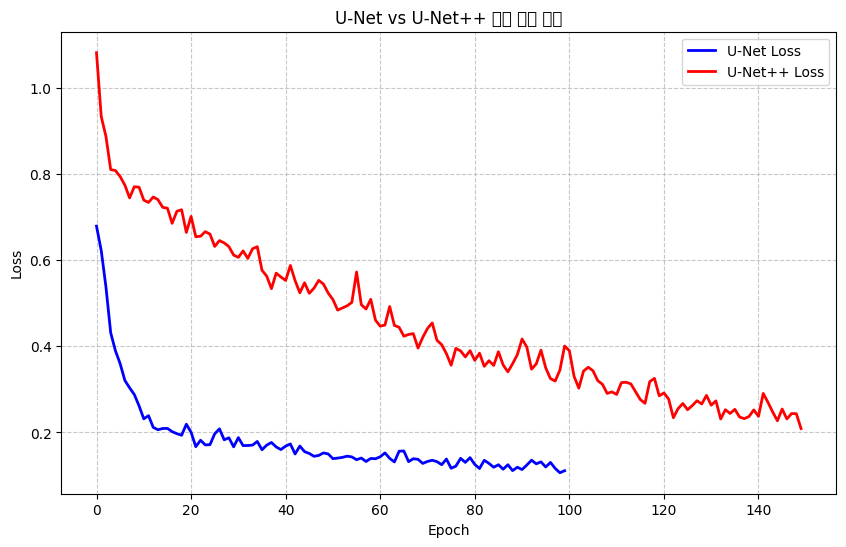

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# U-Net 손실 기록 시각화
# 'unet_loss_history' 변수가 전역에 정의되어 있고 비어 있지 않은 경우에만 플롯합니다.
if 'unet_loss_history' in globals() and unet_loss_history:
    plt.plot(unet_loss_history, label='U-Net Loss', color='blue', linewidth=2)
else:
    print("경고: unet_loss_history가 정의되지 않았거나 비어 있습니다. U-Net 학습 셀(ZOlajtEGgY5s)을 먼저 실행하세요.")

# U-Net++ 손실 기록 시각화
# 'unetpp_loss_history' 변수가 전역에 정의되어 있고 비어 있지 않은 경우에만 플롯합니다.
if 'unetpp_loss_history' in globals() and unetpp_loss_history:
    plt.plot(unetpp_loss_history, label='U-Net++ Loss', color='red', linewidth=2)
else:
    print("경고: unetpp_loss_history가 정의되지 않았거나 비어 있습니다. U-Net++ 학습 셀(D1MbF9LWwyeA)을 먼저 실행하세요.")

plt.title('U-Net vs U-Net++ 훈련 손실 비교') # 그래프 제목
plt.xlabel('Epoch') # x축 라벨
plt.ylabel('Loss') # y축 라벨
plt.legend() # 범례 표시
plt.grid(True, linestyle='--', alpha=0.7) # 그리드 표시
plt.show() # 그래프 출력

### U-Net과 U-Net++ 모델 성능 비교 (IoU)

아래는 U-Net과 U-Net++ 모델의 평균 IoU(Intersection over Union) 점수를 직접 비교한 결과입니다. 이 점수는 각 모델이 도로 영역을 얼마나 정확하게 예측했는지 정량적으로 보여줍니다.

In [28]:
print("="*50)
print("모델별 평균 IoU 비교") # 모델별 평균 IoU 비교 제목 출력
print("="*50)
# U-Net과 U-Net++의 평균 IoU 점수 출력
print(f"U-Net 평균 IoU: {unet_iou:.4f}")
print(f"U-Net++ 평균 IoU: {unetpp_iou:.4f}")

# 두 모델의 평균 IoU를 비교하여 결론 출력
if unetpp_iou > unet_iou:
    print("\n결론: U-Net++ 모델이 U-Net 모델보다 더 높은 평균 IoU를 달성했습니다.")
elif unet_iou > unetpp_iou:
    print("\n결론: U-Net 모델이 U-Net++ 모델보다 더 높은 평균 IoU를 달성했습니다.")
else:
    print("\n결론: U-Net과 U-Net++ 모델의 평균 IoU가 동일합니다.")

모델별 평균 IoU 비교
U-Net 평균 IoU: 0.7706
U-Net++ 평균 IoU: 0.7841

결론: U-Net++ 모델이 U-Net 모델보다 더 높은 평균 IoU를 달성했습니다.
